# Independent baseline verification, end to end

This notebook runs the whole analysis on a **synthetic fixture whose answer is known**, so that
every stage can be checked against a truth the algorithm cannot see.

> **Everything below is generated test data.** It describes no real forest, project or party.
> The point is not what the numbers say — it is whether the estimator recovers a counterfactual
> that was hidden from it. For the same pipeline on real INPE PRODES measurements, see
> `prodes_amazon_analysis.ipynb`.

The fixture builds a treated unit as a convex combination of three control parcels, carries that
combination forward past the pretend start year to get the **true counterfactual**, then suppresses
clearing inside the treated unit to produce what it 'actually' did. The pipeline sees only the
pre-treatment years when it chooses and weights controls.

In [1]:
import sys, dataclasses
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from app.config import DEFAULT_CONFIG
from app.services import candidate_filter as cf
from app.services import control_matching as cm
from app.services import feature_engineering as fe
from app.services import trajectory as tj
from app.services.pipeline import run_project_analysis, run_backtest_series
from app.services.placebo_testing import run_placebo_suite
from tests.fixtures.synthetic_forest import build_scenario

plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.25})

scenario = build_scenario(seed=7)
project = scenario.project
pool = scenario.pool

print(f'control pool          : {len(pool)} units, {pool.provenance.kind.value}')
print(f'project               : {project.display_name}, starts {project.start_year}')
print(f'claimed baseline loss : {project.claim.baseline_loss:.1%}')
print()
print('GROUND TRUTH (hidden from the algorithm)')
print(f'  true counterfactual loss : {scenario.true_counterfactual_loss:.3%}')
print(f'  true actual loss         : {scenario.true_actual_loss:.3%}')
print(f'  true avoided             : {scenario.true_avoided:.3%}')
print(f'  true donors              : {scenario.donor_ids} at {scenario.true_weights}')

control pool          : 60 units, synthetic
project               : Synthetic, starts 2011
claimed baseline loss : 30.0%

GROUND TRUTH (hidden from the algorithm)
  true counterfactual loss : 5.309%
  true actual loss         : 2.155%
  true avoided             : 3.154%
  true donors              : ('S003', 'S017', 'S041') at [0.5 0.3 0.2]


## Stages 2–5 — measure the project, using only what predates it

The timing object is the temporal firewall. `pre_period` is the flux window used for covariates;
`pre_stock_window` runs one year later because standing forest on the project's first day is fixed
by earlier clearing and is the level every later loss is measured against.

In [2]:
timing = fe.default_timing(
    start_year=project.start_year,
    pre_years=DEFAULT_CONFIG.pre_period_years,
    last_observed_year=scenario.last_year,
    earliest_data_year=project.footprint.first_year,
)
features = tuple(DEFAULT_CONFIG.matching.features)

print(f'covariates measured over : {timing.pre_period.start}-{timing.pre_period.end} (clearing years)')
print(f'trajectory anchored over : {timing.pre_stock_window.start}-{timing.pre_stock_window.end} (stock years)')
print(f'outcomes observed over   : {timing.effective_post.start}-{timing.effective_post.end}')
print()

project_features = fe.extract_project_features(project, timing, features)
for name, value in project_features.items():
    if value is not None:
        print(f'  {name:26s} {value:12.4f}')

print()
print('pre-treatment forest trajectory (share of forest at window start):')
pre = fe.extract_pre_trajectory(project.footprint, timing)
for year, value in pre:
    print(f'  {year}  {value:.4f}')

covariates measured over : 2003-2010 (clearing years)
trajectory anchored over : 2003-2011 (stock years)
outcomes observed over   : 2011-2020

  forest_cover                     0.8292
  historical_loss_rate             0.0053
  historical_loss_trend            0.0000
  elevation                      494.4401
  slope                            8.5034
  distance_to_road                23.8210
  distance_to_settlement          44.1304
  population_density               9.3127
  cropland_percentage              0.1074
  precipitation                 2059.5974
  latitude                        -6.7000

pre-treatment forest trajectory (share of forest at window start):
  2003  1.0000
  2004  0.9948
  2005  0.9892
  2006  0.9841
  2007  0.9789
  2008  0.9737
  2009  0.9685
  2010  0.9630
  2011  0.9577


## Stages 6–9 — eligible land, then similar land, then land that behaved similarly

Three filters in sequence. Eligibility has nothing to do with similarity: a protected parcel can
match on every covariate and still be useless, because protection is the treatment being priced.
Every exclusion is recorded with a reason — the share of the pool discarded is itself a
confidence signal.

In [3]:
candidates = cf.filter_candidate_controls(project, pool, timing, DEFAULT_CONFIG.matching)
print('candidate pool:', candidates.summary())

matching = cm.match_controls(project, candidates.units, timing, DEFAULT_CONFIG.matching)
print()
print(f'matched {len(matching)} controls on {len(matching.features_used)} covariates')
print(f'caliper relaxed: {matching.caliper_relaxed}')
print()
print(f"{'control':10s} {'distance':>9s} {'similarity':>11s}  nearest covariates")
for m in matching.matches[:8]:
    top = sorted(m.feature_differences, key=lambda d: -d.similarity)[:3]
    detail = ', '.join(f'{d.name}={d.similarity:.2f}' for d in top)
    print(f'{m.unit_id:10s} {m.distance:9.3f} {m.similarity:11.3f}  {detail}')

candidate pool: {'considered': 60, 'eligible': 59, 'rejected': 1, 'rejection_rate': 0.0167, 'reasons': {'leakage_buffer': 1}}

matched 52 controls on 11 covariates
caliper relaxed: False

control     distance  similarity  nearest covariates
S029           0.404       0.817  distance_to_settlement=0.98, population_density=0.98, historical_loss_trend=0.97
S033           0.478       0.788  distance_to_settlement=0.93, cropland_percentage=0.92, historical_loss_rate=0.87
S019           0.573       0.751  latitude=0.97, distance_to_road=0.96, forest_cover=0.96
S026           0.595       0.743  historical_loss_trend=0.89, distance_to_road=0.85, historical_loss_rate=0.78
S044           0.602       0.740  forest_cover=0.96, distance_to_settlement=0.94, precipitation=0.92
S004           0.632       0.729  historical_loss_trend=0.94, distance_to_road=0.88, historical_loss_rate=0.83
S001           0.656       0.720  historical_loss_trend=0.99, distance_to_road=0.93, distance_to_settlement=0.83
S03

In [4]:
control_pres = {m.unit_id: fe.extract_pre_trajectory(m.unit, timing) for m in matching.matches}
traj = tj.filter_by_trajectory(pre, control_pres, DEFAULT_CONFIG.trajectory)
print('trajectory filter:', traj.summary())

worst = sorted(traj.scores, key=lambda s: -s.rmse)[:3]
best = sorted(traj.scores, key=lambda s: s.rmse)[:3]
print()
print('closest pre-treatment histories:')
for s in best:
    print(f'  {s.unit_id:10s} rmse={s.rmse:.5f} corr={s.correlation:+.3f}')
print('furthest, and why they were rejected:')
for s in worst:
    print(f'  {s.unit_id:10s} rmse={s.rmse:.5f} {s.reason[:70]}')

trajectory filter: {'evaluated': 52, 'kept': 40, 'rejected': 12, 'relaxed_to_meet_minimum': False, 'note': ''}

closest pre-treatment histories:
  S015       rmse=0.00060 corr=+1.000
  S032       rmse=0.00067 corr=+1.000
  S036       rmse=0.00116 corr=+1.000
furthest, and why they were rejected:
  S006       rmse=0.02367 path differs by 0.0237 RMSE against a limit of 0.0136 (the project's o
  S020       rmse=0.02267 path differs by 0.0227 RMSE against a limit of 0.0136 (the project's o
  S028       rmse=0.02123 path differs by 0.0212 RMSE against a limit of 0.0136 (the project's o


## Stages 10–14 — fit the weights, lock them, then look at the outcome

`run_project_analysis` performs the whole sequence. Weights are frozen into an immutable
`SyntheticControlFit` before any post-treatment series is read; the optimiser is only ever handed
`PreTreatmentView` objects, which raise if asked for a year at or after the start.

In [5]:
result = run_project_analysis(project, pool)
fit = result.fit

print('SYNTHETIC CONTROL')
print(f'  pre-treatment RMSE   : {fit.pre_rmse:.6f}')
print(f'  effective controls   : {fit.effective_controls:.2f} of {len(fit.control_ids)} donors')
print(f'  largest single weight: {fit.max_weight:.1%}')
print(f'  solver               : {fit.solver} ({fit.status})')
print()
print('  weights:')
for unit_id, weight in fit.contributing[:8]:
    flag = '  <- a true donor' if unit_id in scenario.donor_ids else ''
    print(f'    {unit_id:10s} {weight:6.3f}{flag}')

SYNTHETIC CONTROL
  pre-treatment RMSE   : 0.000558
  effective controls   : 5.11 of 40 donors
  largest single weight: 34.3%
  solver               : CLARABEL (optimal)

  weights:
    S033        0.343
    S000        0.157
    S007        0.136
    S039        0.125
    S019        0.094
    S001        0.089
    S041        0.053  <- a true donor
    S005        0.002


In [6]:
imp = result.impact
print('THE COMPARISON')
print(f"  claimed baseline loss        {imp.claimed_baseline:8.2%}")
print(f"  observed loss in project     {imp.actual_loss:8.2%}")
print(f"  independent counterfactual   {imp.counterfactual_loss:8.2%}"
      f"   95% CI [{result.interval.lower:.2%}, {result.interval.upper:.2%}]")
print()
print(f"  claimed avoided              {imp.claimed_avoided:8.2%}")
print(f"  independently supported      {imp.estimated_avoided:8.2%}")
print(f"  supported fraction           {imp.supported_fraction:8.1%}")
print(f"  potential over-crediting     {imp.potential_overcrediting:8.1%}")
print()
print('AGAINST THE HIDDEN TRUTH')
err = imp.counterfactual_loss - scenario.true_counterfactual_loss
print(f'  true counterfactual          {scenario.true_counterfactual_loss:8.2%}')
print(f'  estimate error               {err:+8.3%}')
print(f'  truth inside the interval    {result.interval.contains(scenario.true_counterfactual_loss)}')
print()
for line in result.interpretation():
    print(' *', line)

THE COMPARISON
  claimed baseline loss          30.00%
  observed loss in project        2.16%
  independent counterfactual      5.47%   95% CI [5.25%, 5.68%]

  claimed avoided                27.84%
  independently supported         3.32%
  supported fraction              11.9%
  potential over-crediting        88.1%

AGAINST THE HIDDEN TRUTH
  true counterfactual             5.31%
  estimate error                +0.164%
  truth inside the interval    True

 * Independent counterfactual analysis supports approximately 12% of the avoided deforestation this project claims over the window analysed.
 * The submitted baseline of 30.0% is 24.5 percentage points above the 5.5% that comparable untreated forest actually lost over the same period. This is a discrepancy between a projection and an estimate, and is not in itself evidence of error or misconduct.
 * Estimated counterfactual loss 5.5%, 95% interval 5.3% to 5.7%. The counterfactual cannot be observed; this range reflects sensitivity 

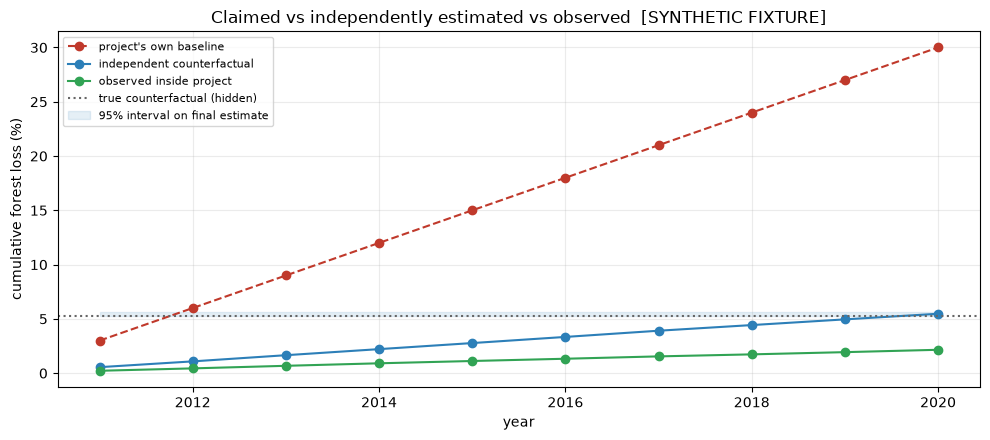

In [7]:
years = [r['year'] for r in result.timeline]
proj = [r['project_loss'] for r in result.timeline]
synth = [r['counterfactual_loss'] for r in result.timeline]
claim = [r['claimed_loss'] for r in result.timeline]

fig, ax = plt.subplots()
ax.plot(years, np.array(claim) * 100, 'o--', color='#c0392b', label="project's own baseline")
ax.plot(years, np.array(synth) * 100, 'o-', color='#2c7fb8', label='independent counterfactual')
ax.plot(years, np.array(proj) * 100, 'o-', color='#31a354', label='observed inside project')
ax.axhline(scenario.true_counterfactual_loss * 100, color='#666', ls=':', label='true counterfactual (hidden)')
ax.fill_between(years, result.interval.lower * 100, result.interval.upper * 100,
                color='#2c7fb8', alpha=0.12, label='95% interval on final estimate')
ax.set_xlabel('year'); ax.set_ylabel('cumulative forest loss (%)')
ax.set_title('Claimed vs independently estimated vs observed  [SYNTHETIC FIXTURE]')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

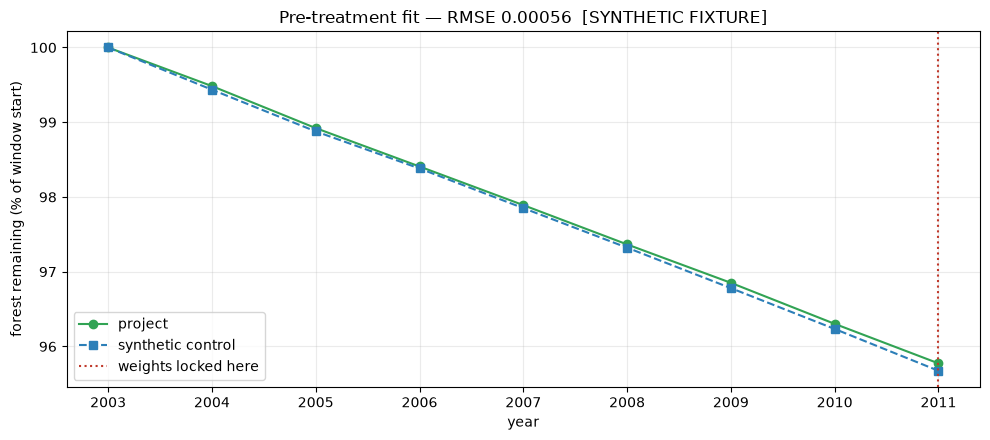

In [8]:
pre_years = list(result.timing.pre_stock_window.years)
p_series = [result.project_series[y] for y in pre_years]
s_series = [result.synthetic_series[y] for y in pre_years]

fig, ax = plt.subplots()
ax.plot(pre_years, np.array(p_series) * 100, 'o-', color='#31a354', label='project')
ax.plot(pre_years, np.array(s_series) * 100, 's--', color='#2c7fb8', label='synthetic control')
ax.axvline(project.start_year, color='#c0392b', ls=':', label='weights locked here')
ax.set_xlabel('year'); ax.set_ylabel('forest remaining (% of window start)')
ax.set_title(f'Pre-treatment fit — RMSE {result.fit.pre_rmse:.5f}  [SYNTHETIC FIXTURE]')
ax.legend(); plt.tight_layout(); plt.show()

## Stage 16 — the analysis reporting on its own reliability

A near-perfect pre-treatment fit is *not* sufficient evidence that the right donors were found.
With a short pre-period and many donors the trajectory objective is badly underdetermined: many
different weightings reproduce the pre-period to within 1e-4 and then diverge afterwards. That is
why effective control count and weight concentration are reported next to RMSE rather than behind
it.

In [9]:
for key, value in result.quality.as_dict().items():
    if key != 'warnings':
        print(f'  {key:28s} {value}')
print()
for warning in result.quality.warnings:
    print('  ! ' + warning)

print()
print('RISK, decomposed')
risk = result.risk
print(f'  score {risk.score:.1f} ({risk.level}), signal {risk.raw_signal:.1f} '
      f'scaled by confidence {risk.confidence_multiplier:.2f}')
for component in risk.components:
    print(f'    [{component.role:10s}] {component.label:26s} {component.score:6.1f}')

  pre_treatment_rmse           0.00056
  pre_treatment_mae            0.00049
  pre_treatment_correlation    0.9999
  pre_treatment_fit            0.959
  effective_controls           5.11
  max_single_weight            0.3426
  contributing_controls        9
  control_match_quality        0.7769
  mean_match_distance          0.7574
  geographic_spread_km         1838.3
  covariate_balance_share      0.3636
  candidate_rejection_rate     0.0167
  confidence_interval_width    0.00425
  bootstrap_convergence        1.0
  confidence                   MODERATE

  ! Only 36% of covariates reached acceptable balance after matching.

RISK, decomposed
  score 84.9 (SEVERE), signal 92.9 scaled by confidence 0.91
    [signal    ] Unsupported share of claim   88.1
    [signal    ] Claim against supported range  100.0
    [confidence] Pre-treatment fit            95.9
    [confidence] Control match quality        77.7
    [confidence] Estimate precision           97.9


## Stage 17 — placebo tests: does the estimator work at all?

Take parcels that were never treated, pretend a project started on each, hide the future, predict,
and score the prediction against what actually happened. Because nothing was treated, the observed
history *is* the true counterfactual.

This is the only number in the system that measures its own accuracy rather than estimating
something unobservable.

In [10]:
fast = DEFAULT_CONFIG.with_(
    uncertainty=dataclasses.replace(DEFAULT_CONFIG.uncertainty, n_bootstrap=100)
)
suite = run_placebo_suite(
    pool, pseudo_start_years=[2011], config=fast, max_units=25,
    min_forest_km2=100.0, include_bootstrap=True,
)
metrics = suite.metrics()
for key in ('n', 'n_failed', 'mae', 'rmse', 'bias', 'median_error',
            'p90_absolute_error', 'interval_coverage'):
    print(f'  {key:22s} {metrics[key]}')
print()
for line in metrics['interpretation']:
    print(' *', line)

  n                      25
  n_failed               0
  mae                    0.0021
  rmse                   0.00264
  bias                   3e-05
  median_error           -0.00013
  p90_absolute_error     0.00423
  interval_coverage      0.6

 * Mean signed error +0.003% of forest cover - no material bias in either direction.
 * Only 60% of true outcomes fell inside the nominal 95% interval. The intervals are too narrow and every confidence statement built on them overstates precision.


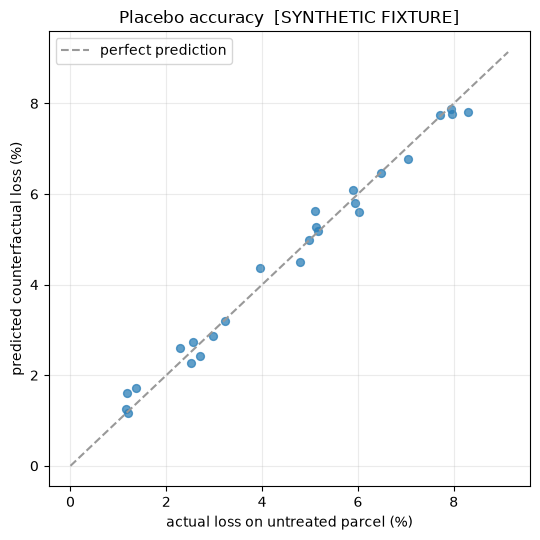

In [11]:
predicted = np.array([r.predicted_loss for r in suite.results]) * 100
actual = np.array([r.actual_loss for r in suite.results]) * 100

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lim = max(predicted.max(), actual.max()) * 1.1
ax.plot([0, lim], [0, lim], color='#999', ls='--', label='perfect prediction')
ax.scatter(actual, predicted, s=32, alpha=0.75, color='#2c7fb8')
ax.set_xlabel('actual loss on untreated parcel (%)')
ax.set_ylabel('predicted counterfactual loss (%)')
ax.set_title('Placebo accuracy  [SYNTHETIC FIXTURE]')
ax.legend(); plt.tight_layout(); plt.show()

## Stage 18 — backtesting: what would this have said at the time?

Each row re-runs the entire pipeline with everything after `cutoff_year` withheld. This is not a
truncation of the output — the counterfactual, the interval and the risk score are all recomputed
as they would have been on that date, which is what makes the claim 'we would have flagged this in
year N' meaningful rather than retrospective.

In [12]:
rows = run_backtest_series(
    project, pool, cutoff_years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
)
header = f"{'as of':>6s} {'yrs':>4s} {'counterfactual':>15s} {'project':>9s} {'supported':>10s} {'risk':>6s} {'confidence':>11s}"
print(header)
for row in rows:
    if 'error' in row:
        print(f"{row['cutoff_year']:6d}  {row['error'][:60]}")
        continue
    supported = '-' if row['supported_fraction'] is None else f"{row['supported_fraction']:.0%}"
    print(f"{row['cutoff_year']:6d} {row['years_observed']:4d} {row['counterfactual_loss']:15.2%} "
          f"{row['project_loss']:9.2%} {supported:>10s} {row['risk_score']:6.1f} {row['confidence']:>11s}")

 as of  yrs  counterfactual   project  supported   risk  confidence
  2013    3           1.66%     0.68%         3%   71.3    MODERATE
  2014    4           2.21%     0.91%         4%   70.7    MODERATE
  2015    5           2.77%     1.12%         6%   70.0    MODERATE
  2016    6           3.34%     1.33%         7%   69.3    MODERATE
  2017    7           3.91%     1.55%         8%   68.6    MODERATE
  2018    8           4.43%     1.73%        10%   67.9    MODERATE
  2019    9           4.96%     1.94%        11%   67.2    MODERATE
  2020   10           5.47%     2.15%        12%   66.6    MODERATE


## What this notebook does and does not establish

**Establishes.** The pipeline recovers a counterfactual that was hidden from it, on generated data,
to within a fraction of a percentage point, with the confidence interval covering the truth most of
the time. The temporal firewall holds: corrupting post-cutoff data does not move the estimate
(`tests/test_temporal_integrity.py`).

**Does not establish.** That the estimator is this accurate on real forest. Synthetic data is
generated by assumptions, and an estimator validated only against a generator has been validated
against whoever wrote it. On real INPE PRODES parcels the same placebo procedure gives a median
error near zero but a mean absolute error of about **4 percentage points** and interval coverage of
about **62%** against a nominal 95% — see `prodes_amazon_analysis.ipynb`. Real land is much harder
than a well-specified fixture, and the intervals as currently constructed are too narrow.

That gap is the honest headline, and it is why the bootstrap documents itself as a *lower bound* on
total uncertainty.